# 2.5 Image Recognition

#### 1. Import libraries and load data
#### 2. CNN to categorize images
#### 3. Test epochs required

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#download the weather images and put them in a directory
path = '/content/drive/MyDrive/Colab Notebooks/Multi-class Weather Dataset'
folders = os.listdir(path)
print(folders)

['Rain', 'Cloudy', 'Shine', 'Sunrise']


In [7]:
#this will load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


#### 2. CNN to categorize images

In [8]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

#### 3. Test epochs required

In [37]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator,
    epochs = 10, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 138s 5s/step - accuracy: 0.9456 - loss: 0.0197 - val_accuracy: 0.8795 - val_loss: 0.0563
Epoch 2/10
 1/28 ━━━━━━━━━━━━━━━━━━━━ 1:30 3s/step - accuracy: 1.0000 - loss: 0.0019

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 415ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8661 - val_loss: 0.0592
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 178s 4s/step - accuracy: 0.9537 - loss: 0.0180 - val_accuracy: 0.8750 - val_loss: 0.0615
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 345ms/step - accuracy: 0.9688 - loss: 0.0045 - val_accuracy: 0.8839 - val_loss: 0.0539
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.9927 - loss: 0.0029 - val_accuracy: 0.8839 - val_loss: 0.0517
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 399ms/step - accuracy: 0.9688 - loss: 0.0181 - val_accuracy: 0.8884 - val_loss: 0.0509
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.9928 - loss: 0.0032 - val_accuracy: 0.8795 - val_loss: 0.0574
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 24s 759ms/step - accuracy: 1.0000 - loss: 7.3829e-07 - val_accuracy: 0.8705 - val_loss: 0.0623
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 123s 4s/step - accuracy: 0.9604 - loss: 0.0175 - val_accuracy: 0.8080 - 

In [38]:
results = pd.DataFrame(model.history.history)

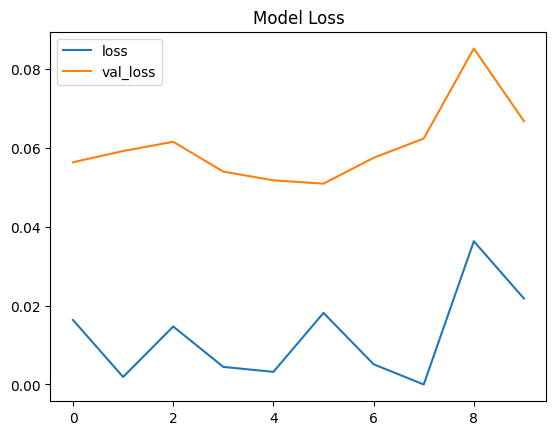

In [39]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

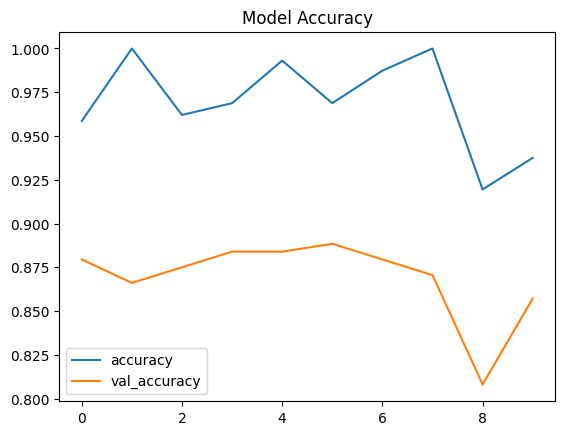

In [40]:
results[['accuracy','val_accuracy']].plot(title='Model Accuracy')
plt.savefig('./accuracy.png')

In [41]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.9375, Val_Accuracy: 0.8571428656578064
Loss: 0.02178793027997017, Val_Loss: 0.06673960387706757


11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


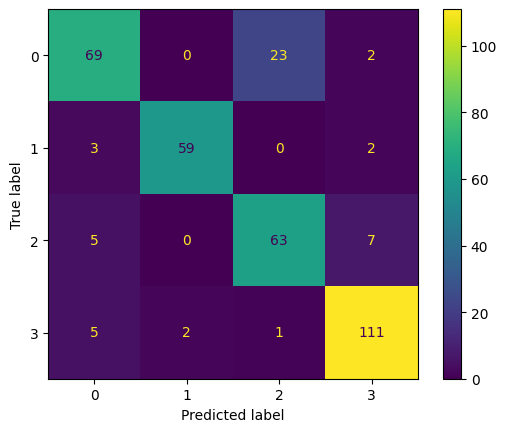

In [42]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [43]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


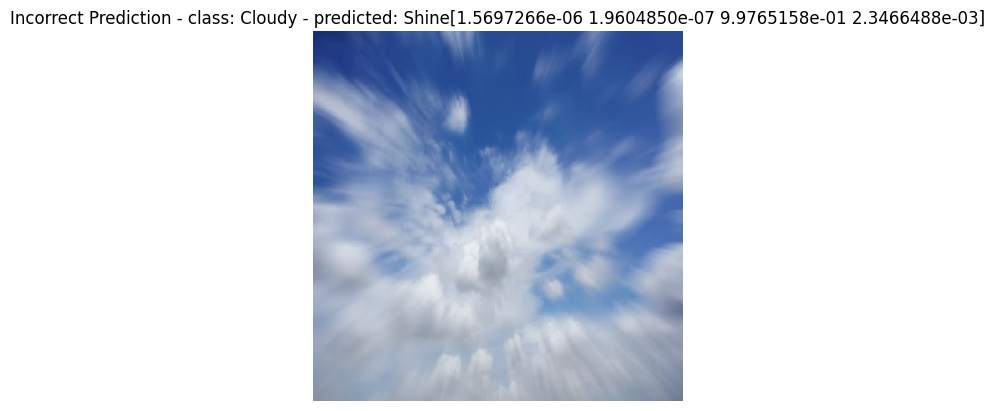

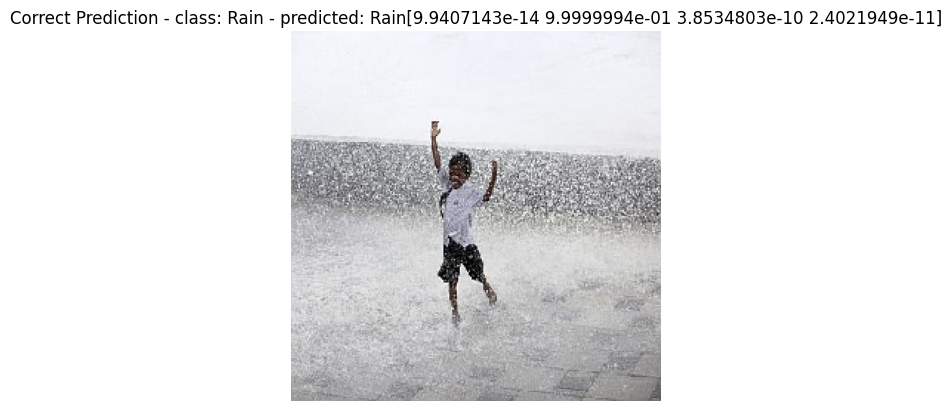

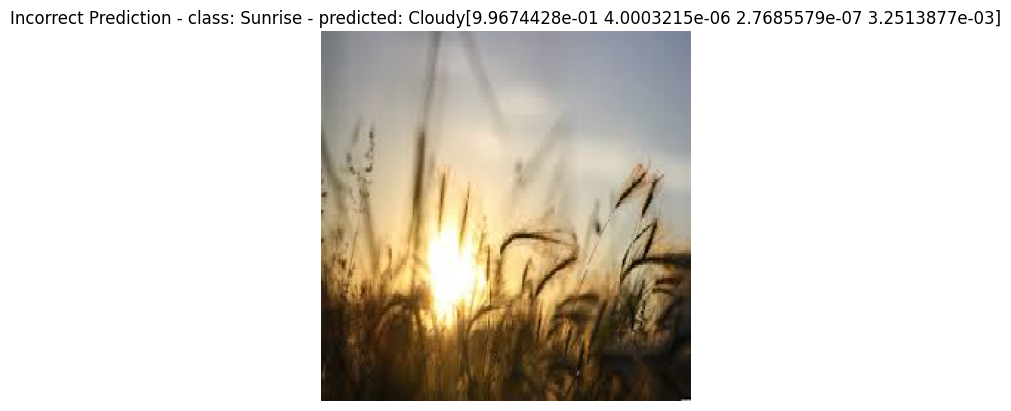

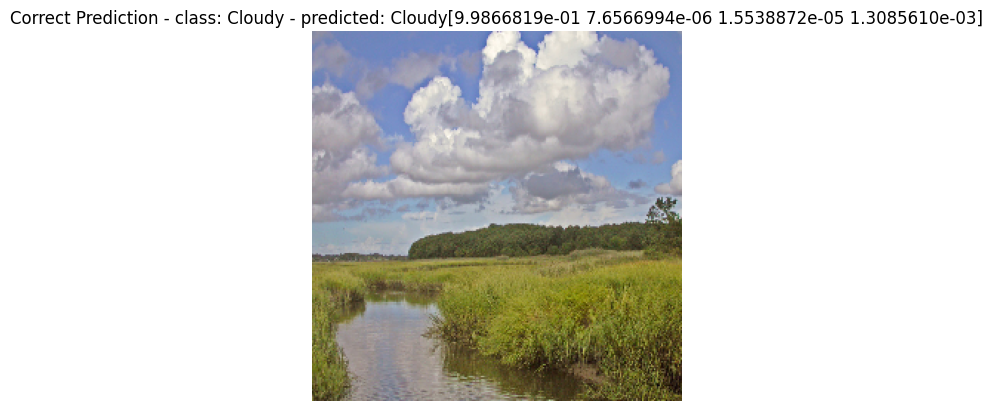

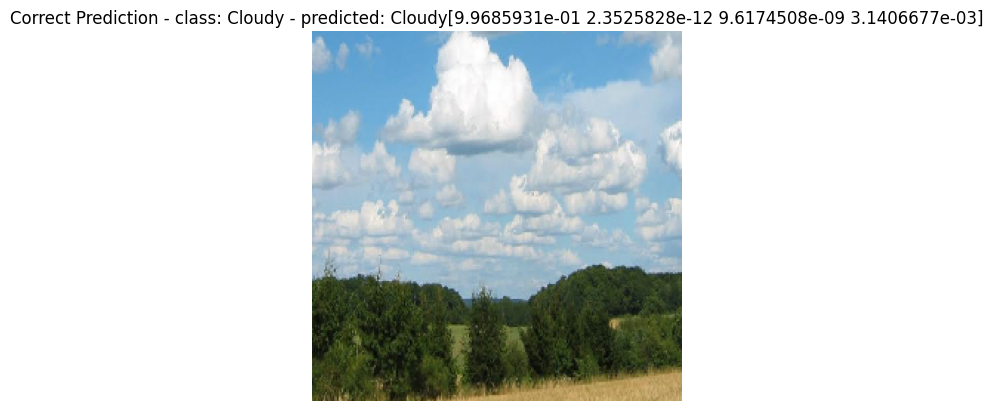

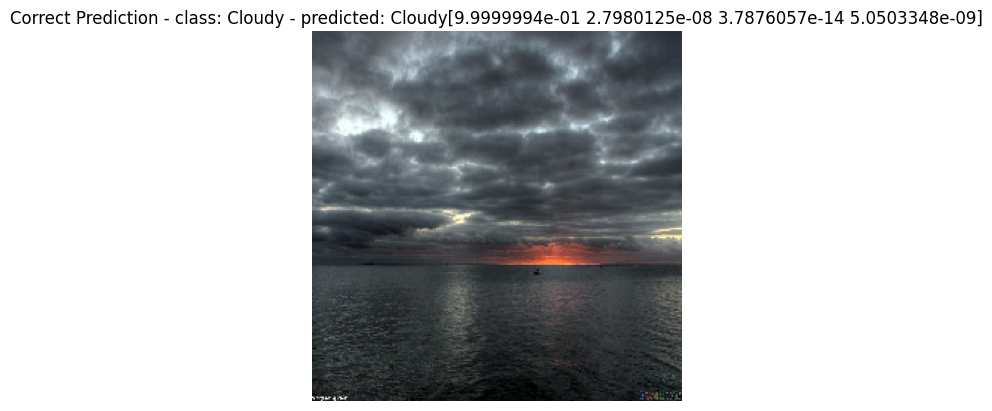

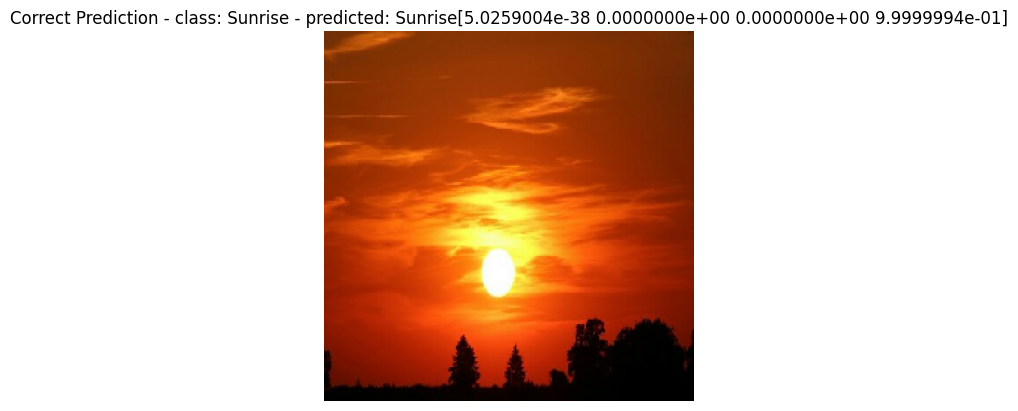

In [45]:
predict_one(model, 7) #<--you can show multiple pictures with this command. Just fill in the number you want to see.